# 03 — SARIMA Model

Fit `SARIMA(1,1,1)(1,1,1,24)` on the training window, forecast 720 hours ahead, and evaluate against the held-out test set.

Inputs: `data/processed/train.parquet`, `data/processed/test.parquet`  
Outputs: `models/sarima_pjme.pkl`, `results/figures/sarima_*.png`, `results/metrics.json`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELS = PROJECT_ROOT / 'models'
FIGS = PROJECT_ROOT / 'results' / 'figures'
METRICS = PROJECT_ROOT / 'results' / 'metrics.json'
for d in (MODELS, FIGS):
    d.mkdir(parents=True, exist_ok=True)

import pandas as pd

from src.sarima_model import (
    DEFAULT_ORDER, DEFAULT_SEASONAL_ORDER,
    fit_sarima, forecast, save_model,
)
from src.evaluation import (
    mae, rmse, plot_forecast, plot_residual_acf, residual_diagnostics, append_metrics,
)

In [2]:
train = pd.read_parquet(PROCESSED / 'train.parquet')['PJME_MW']
test = pd.read_parquet(PROCESSED / 'test.parquet')['PJME_MW']
train.index.freq = 'h'
test.index.freq = 'h'
print(f'Train: {len(train):,} rows | Test: {len(test):,} rows')

Train: 17,520 rows | Test: 720 rows


## Fit

May take several minutes on ~17k hourly observations.

In [3]:
fit = fit_sarima(train, order=DEFAULT_ORDER, seasonal_order=DEFAULT_SEASONAL_ORDER)
print(fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                            PJME_MW   No. Observations:                17520
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood             -123591.020
Date:                            Sat, 25 Apr 2026   AIC                         247192.039
Time:                                    18:25:27   BIC                         247230.880
Sample:                                07-04-2016   HQIC                        247204.830
                                     - 07-04-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5893      0.005    121.184      0.000       0.580       0.599
ma.L1          0.4683      0.004   

In [4]:
save_model(fit, MODELS / 'sarima_pjme.pkl')

## Forecast 720 hours

In [ ]:
point, conf = forecast(fit, steps=len(test))
point.index = test.index
conf.index = test.index

# Confidence intervals: for 720-hour SARIMA forecasts the analytical CIs from
# statsmodels widen to nonsensical bounds (negative load). They are kept in
# `conf` for inspection but omitted from the plot.
fig = plot_forecast(
    train_tail=train.iloc[-24*14:],
    test=test,
    point_forecast=point,
    conf_int=None,
)
fig.savefig(FIGS / 'sarima_forecast.png', dpi=120)

## Evaluate

In [6]:
metrics = {
    'MAE': mae(test, point),
    'RMSE': rmse(test, point),
    **residual_diagnostics(fit, lags=24),
    'order': list(DEFAULT_ORDER),
    'seasonal_order': list(DEFAULT_SEASONAL_ORDER),
}
print(metrics)

{'MAE': 11661.503185610807, 'RMSE': 12932.369324809704, 'ljung_box_stat': 1065.4814716571611, 'ljung_box_pvalue': 1.079446379216693e-209, 'lags': 24, 'order': [1, 1, 1], 'seasonal_order': [1, 1, 1, 24]}


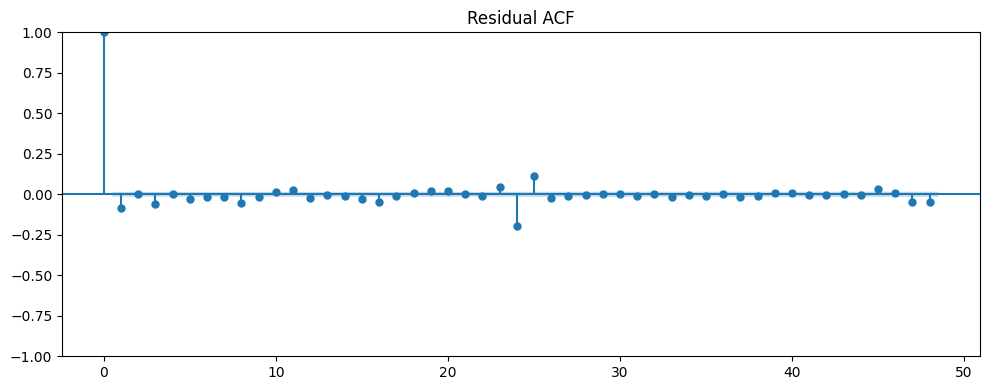

In [7]:
fig = plot_residual_acf(fit, lags=48)
fig.savefig(FIGS / 'sarima_residual_acf.png', dpi=120)

In [8]:
append_metrics(METRICS, model='SARIMA', region='PJME', horizon=len(test), metrics=metrics)
print(f'Appended SARIMA result to {METRICS}')

Appended SARIMA result to /Users/karrar/Documents/GitHub/BA26-01-Time-Series/Code/Python/EnergyDemandForecaster/results/metrics.json
